# 🛒 E-Commerce Channel ROI — Analysis
**Dataset:** 6 relational tables · ~133K rows · 51 columns · 3.5 years (2023–2026)  
**Author:** Holarbrain | [holarbrain.github.io](https://holarbrain.github.io)  
**Stack:** Python · pandas · matplotlib · seaborn

---


# Channel ROI Analysis
This notebook performs an analysis of return on investment (ROI) across different marketing channels using the provided e-commerce datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the datasets
interactions = pd.read_csv('/content/interactions.csv')
products = pd.read_csv('/content/products.csv')
purchases = pd.read_csv('/content/purchases.csv')
reviews = pd.read_csv('/content/reviews.csv')
sessions = pd.read_csv('/content/sessions.csv')
users = pd.read_csv('/content/users.csv')

print('Data loaded successfully.')

Data loaded successfully.


In [2]:
# Preview the sessions data to identify channel information
display(sessions.head())
display(purchases.head())

,session_id,user_id,start_time,device_type,referrer_source,is_converted
0,6d553c2d-fe1e-4406-9e32-cd258df05830,0000780a-2126-4e84-9622-42ce0ea9b17a,2023-01-16 12:57:18.000000115,desktop,organic_search,False
1,7330ad09-21cd-4849-b1c8-528d72f7d23b,0000780a-2126-4e84-9622-42ce0ea9b17a,2023-01-18 09:20:23.000000548,desktop,display_ad,False
2,6f6dce62-c078-4dfd-b39b-33068358bc0a,000aea63-23ad-42ab-98b8-3de2e33c624c,2024-10-17 02:05:24.000000257,desktop,direct,False
3,d3a0ecd7-69c3-431e-bab2-89946ce644c1,000b86cc-387b-4968-aaa5-7152296985d2,2026-02-11 03:24:48.000000440,mobile,direct,False
4,1539d203-2ced-4a39-b32c-79caf3b0db72,000b86cc-387b-4968-aaa5-7152296985d2,2026-02-12 16:41:52.000000696,mobile,organic_search,False


,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date
0,6a57a9c2-5d12-441f-8bde-2781458c6da7,b5d39dff-18ce-4032-8d8d-02db73e5c09e,d669cbc4-2606-49ef-b643-b902b1f0b196,af3bccbc-763f-4162-a178-bf20bfaeccba,003fc1af-ae18-4436-acd7-e4936459c620,ce36fbcb-a957-4388-8717-b8cf3041685a,2,5.74,11.48,2023-01-15 18:05:44.055402424
1,4d758486-b0bd-41d5-84cc-921d01ec3a6a,924f67e7-aac8-49bd-abc7-19339a24fb85,dfd9ccd9-9288-45cd-a1cf-f9c08e2a1b37,0c70a612-d55e-4879-9bce-299d323437f3,6106d434-cac5-40b3-b2a5-0d88a989ed26,9e36d37a-f610-483a-88e0-33b14973265f,2,79.42,158.84,2023-01-19 18:02:11.094635944
2,014ee443-7bdc-4a83-9f9c-4977a112758d,d7ee3884-ce84-451c-876c-2f7fef3d9751,056ebd8a-199a-47fe-867d-8e1698993134,920a8047-d219-4f21-bf1e-9904f1097bad,15bf8d57-5b7d-46a6-9ea9-df3b5ab3c941,d4462a4c-4f04-4b9c-b66d-1e0c82b58377,1,10.71,10.71,2023-01-31 19:52:13.995509927
3,5517e5d5-59ed-4c0b-8e23-1a50d851b33d,d7ee3884-ce84-451c-876c-2f7fef3d9751,056ebd8a-199a-47fe-867d-8e1698993134,5d836ef6-20f0-47c1-9a54-791a4bfeded1,15bf8d57-5b7d-46a6-9ea9-df3b5ab3c941,a24d3211-ac7f-4e4d-9c38-820225b51b67,1,16.21,16.21,2023-01-31 19:52:36.542442866
4,1aef1fd5-cdd4-4e31-9c7c-e6e620bb0386,00c0ba74-a756-4ebf-8748-d9970e12bf38,ada8b2e5-53bb-489a-b8a7-e9a013f4d886,6651c3ab-c7be-4131-b324-68bd0218eb2c,0d07cf8a-4d46-4c9d-a6bd-bcb295d692b7,5aeb69e3-e174-41dd-bc7f-923650d78204,4,67.97,271.88,2023-02-04 03:01:26.725098189


### Channel ROI Calculation Logic
To calculate ROI, we typically need:
1. **Revenue per channel**: Calculated by joining `purchases` with `sessions` (which usually contains the traffic source/channel).
2. **Cost per channel**: This often comes from a marketing spend table, but if not present, we can analyze efficiency based on conversion rates per channel.

In [3]:
# Calculate metrics per channel
# 1. Join sessions with purchases to link revenue to channels
purchase_sessions = pd.merge(
    sessions[['session_id', 'referrer_source', 'is_converted']],
    purchases[['session_id', 'total_amount']],
    on='session_id',
    how='left'
)

# 2. Aggregate Revenue and Session counts
channel_metrics = purchase_sessions.groupby('referrer_source').agg(
    total_sessions=('session_id', 'count'),
    total_conversions=('is_converted', 'sum'),
    total_revenue=('total_amount', 'sum')
).reset_index()

# 3. Calculate Conversion Rate and Revenue Per Session
channel_metrics['conversion_rate'] = (channel_metrics['total_conversions'] / channel_metrics['total_sessions']) * 100
channel_metrics['rev_per_session'] = channel_metrics['total_revenue'] / channel_metrics['total_sessions']

# Display the results
channel_metrics.sort_values(by='total_revenue', ascending=False, inplace=True)
display(channel_metrics)

,referrer_source,total_sessions,total_conversions,total_revenue,conversion_rate,rev_per_session
3,organic_search,7055,618,45728.94,8.759745,6.481777
0,direct,4816,425,33602.15,8.824751,6.977191
6,social_media,2873,245,17330.19,8.527671,6.032088
2,email,1921,177,13007.72,9.213951,6.771327
4,paid_search,1529,141,9787.82,9.221714,6.401452
5,referral,1022,89,6496.63,8.708415,6.356781
1,display_ad,396,42,3557.40,10.606061,8.983333


In [5]:
# Calculate metrics per channel
# 1. Join sessions with purchases to link revenue to channels
purchase_sessions = pd.merge(
    sessions[['session_id', 'referrer_source', 'is_converted']],
    purchases[['session_id', 'total_amount']],
    on='session_id',
    how='left'
)

# 2. Aggregate Revenue and Session counts
channel_metrics = purchase_sessions.groupby('referrer_source').agg(
    total_sessions=('session_id', 'count'),
    total_conversions=('is_converted', 'sum'),
    total_revenue=('total_amount', 'sum')
).reset_index()

# 3. Calculate Conversion Rate and Revenue Per Session
channel_metrics['conversion_rate'] = (channel_metrics['total_conversions'] / channel_metrics['total_sessions']) * 100
channel_metrics['rev_per_session'] = channel_metrics['total_revenue'] / channel_metrics['total_sessions']

# Display the results
channel_metrics.sort_values(by='total_revenue', ascending=False, inplace=True)
display(channel_metrics)

,referrer_source,total_sessions,total_conversions,total_revenue,conversion_rate,rev_per_session
3,organic_search,7055,618,45728.94,8.759745,6.481777
0,direct,4816,425,33602.15,8.824751,6.977191
6,social_media,2873,245,17330.19,8.527671,6.032088
2,email,1921,177,13007.72,9.213951,6.771327
4,paid_search,1529,141,9787.82,9.221714,6.401452
5,referral,1022,89,6496.63,8.708415,6.356781
1,display_ad,396,42,3557.40,10.606061,8.983333


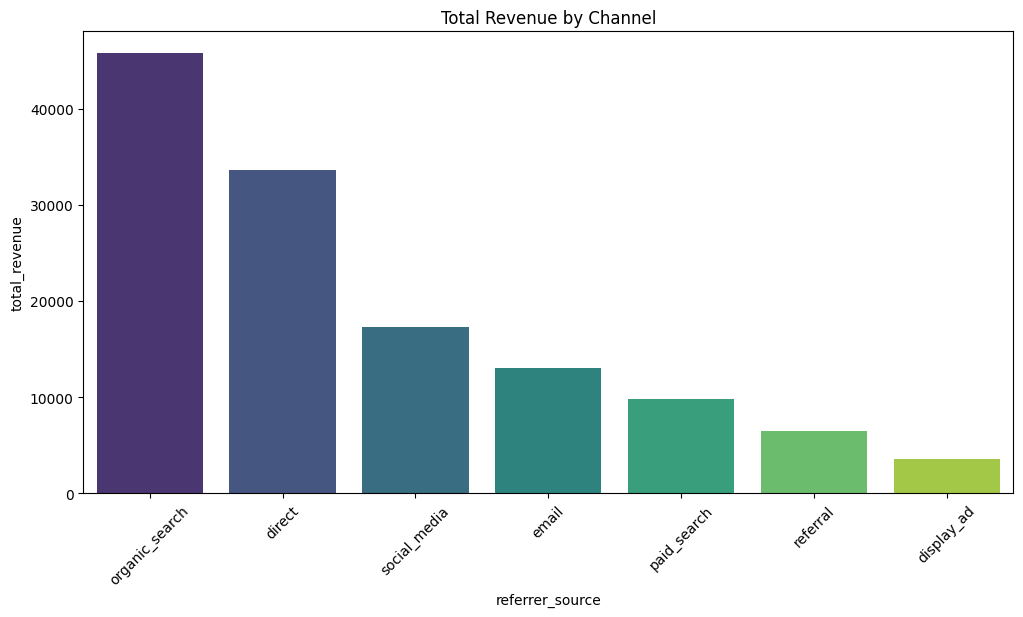

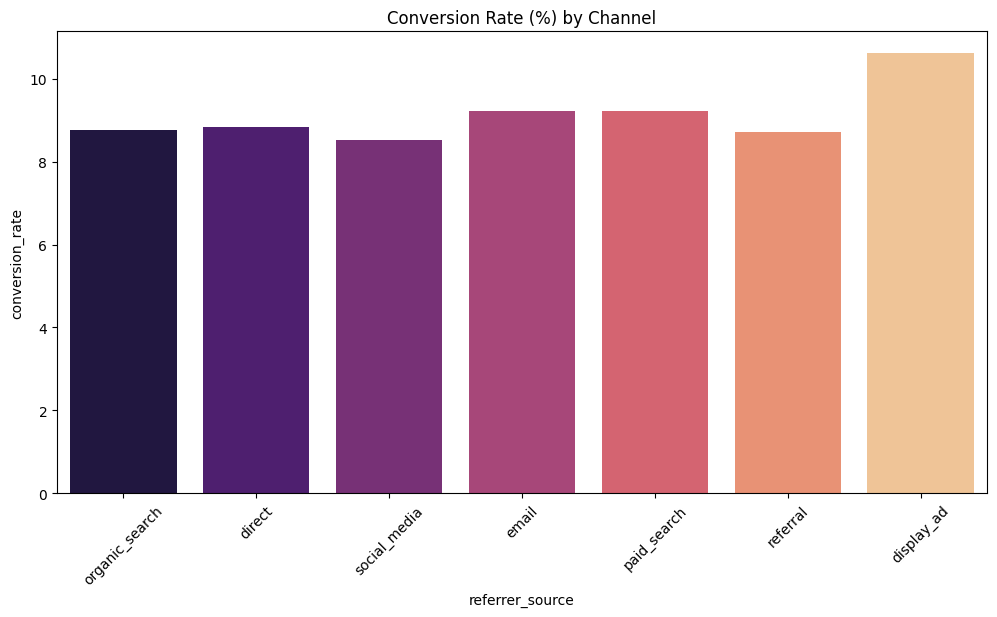

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(data=channel_metrics, x='referrer_source', y='total_revenue', hue='referrer_source', palette='viridis', legend=False)
plt.title('Total Revenue by Channel')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=channel_metrics, x='referrer_source', y='conversion_rate', hue='referrer_source', palette='magma', legend=False)
plt.title('Conversion Rate (%) by Channel')
plt.xticks(rotation=45)
plt.show()

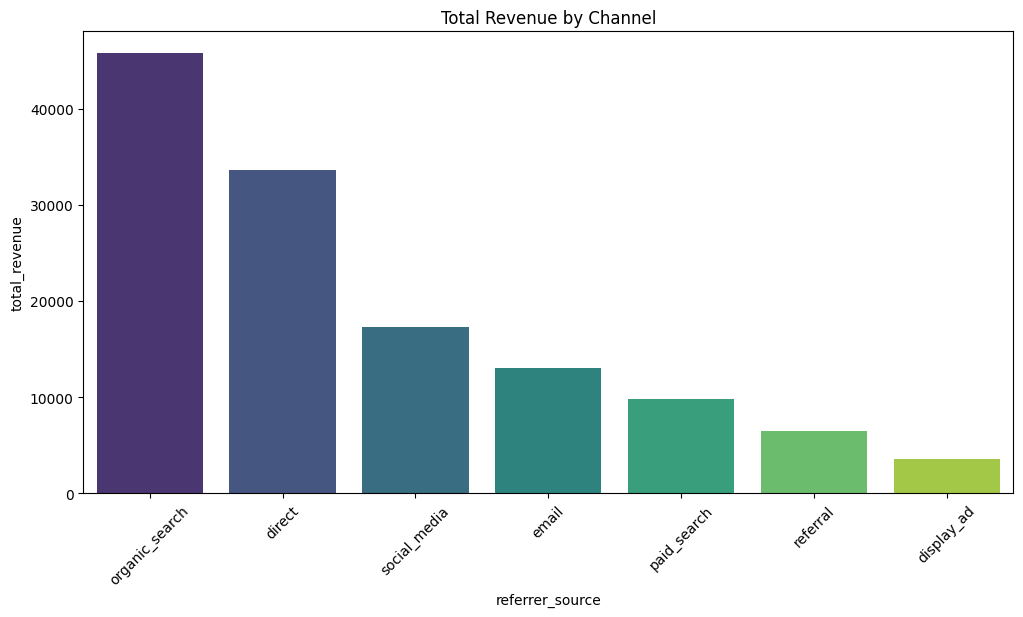

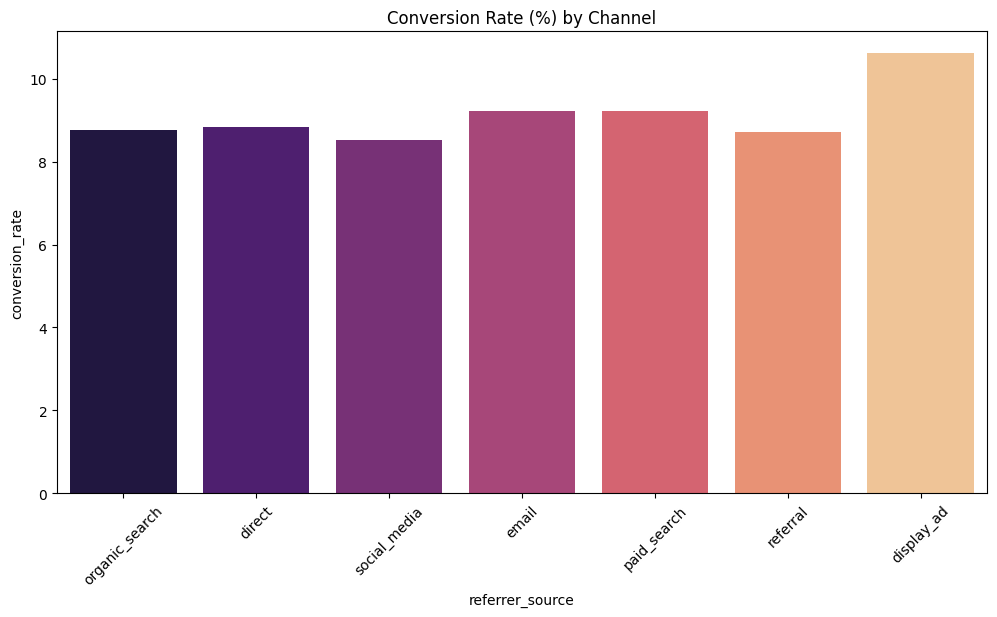

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(data=channel_metrics, x='referrer_source', y='total_revenue', hue='referrer_source', palette='viridis', legend=False)
plt.title('Total Revenue by Channel')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=channel_metrics, x='referrer_source', y='conversion_rate', hue='referrer_source', palette='magma', legend=False)
plt.title('Conversion Rate (%) by Channel')
plt.xticks(rotation=45)
plt.show()

### Analyzing Revenue Per Session (Efficiency Analysis)
While total revenue tells us which channel brings in the most money, **Revenue per Session** reveals the efficiency and profitability of each visit from that channel.

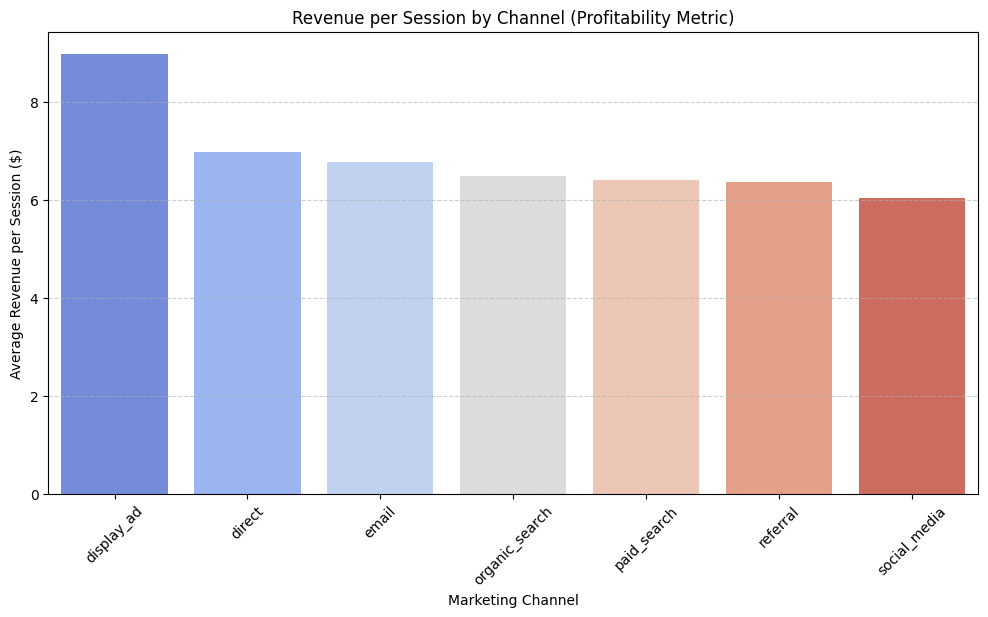

The most profitable source per visit is 'display_ad' with $8.98 per session.


In [7]:
# Sort by revenue per session
profitable_channels = channel_metrics.sort_values(by='rev_per_session', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=profitable_channels, x='referrer_source', y='rev_per_session', palette='coolwarm', hue='referrer_source', legend=False)

plt.title('Revenue per Session by Channel (Profitability Metric)')
plt.ylabel('Average Revenue per Session ($)')
plt.xlabel('Marketing Channel')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Identify the top performer
top_channel = profitable_channels.iloc[0]
print(f"The most profitable source per visit is '{top_channel['referrer_source']}' with ${top_channel['rev_per_session']:.2f} per session.")

### Popular Product Categories in 'display_ad' Channel
Now we dive deeper into the top-performing channel to see which categories drive the most sales.

In [10]:
# 1. Filter sessions for 'display_ad'
display_sessions = sessions[sessions['referrer_source'] == 'display_ad'][['session_id']]

# 2. Join with purchases to get product IDs
display_purchases = pd.merge(display_sessions, purchases, on='session_id')

# 3. Join with products to get categories
display_product_details = pd.merge(display_purchases, products[['product_id', 'category']], on='product_id')

# 4. Aggregate by category
category_popularity = display_product_details.groupby('category').agg(
    units_sold=('quantity', 'sum'),
    total_revenue=('total_amount', 'sum')
).sort_values(by='units_sold', ascending=False).reset_index()

display(category_popularity)

,category,units_sold,total_revenue
0,Home & Kitchen,12,541.33
1,Books,9,281.14
2,Automotive,8,675.46
3,Grocery & Gourmet,8,111.41
4,Clothing & Accessories,8,384.57
5,Electronics,5,963.10
6,Sports & Outdoors,5,505.27
7,Office Products,1,68.49
8,Toys & Games,1,26.63


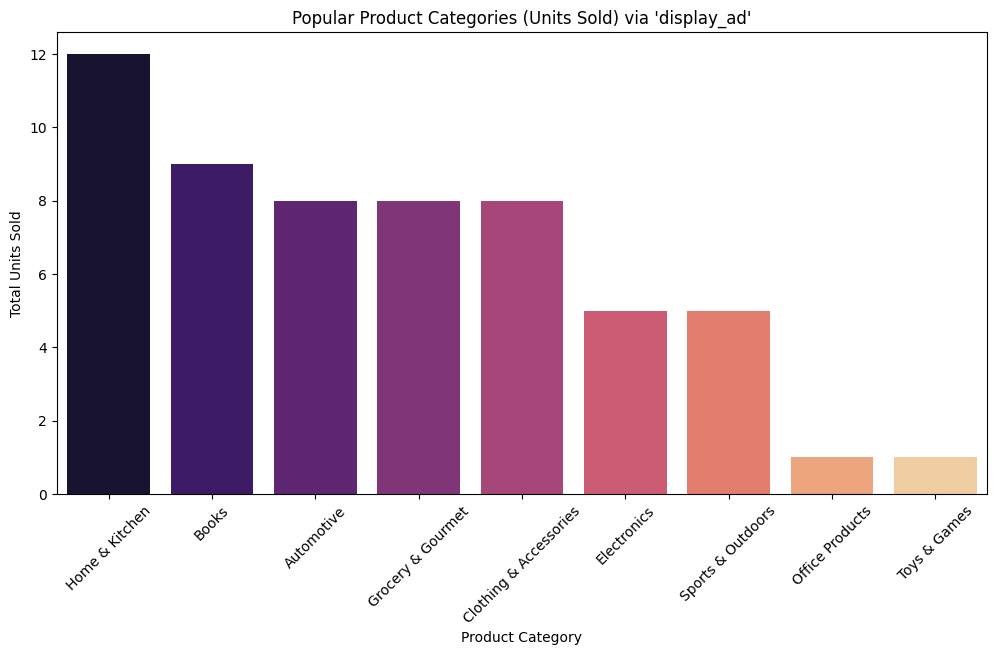

In [11]:
# Visualize Category Popularity
plt.figure(figsize=(12, 6))
sns.barplot(data=category_popularity, x='category', y='units_sold', hue='category', palette='magma', legend=False)
plt.title("Popular Product Categories (Units Sold) via 'display_ad'")
plt.xlabel("Product Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.show()

### Product Category Conversion Rate Analysis
In this section, we analyze how effectively each product category converts browsing sessions into purchases.

In [12]:
# 1. Link interactions/purchases with product categories
# We'll use the 'interactions' table to find total interest (sessions/views) per category
# and 'purchases' to find successful conversions.

# Join interactions with products to get category per interaction
interactions_with_cat = pd.merge(interactions[['session_id', 'product_id']], products[['product_id', 'category']], on='product_id')

# Count unique sessions per category (Total Traffic)
category_traffic = interactions_with_cat.groupby('category')['session_id'].nunique().reset_index(name='total_sessions')

# Join purchases with products to get category per purchase
purchases_with_cat = pd.merge(purchases[['session_id', 'product_id']], products[['product_id', 'category']], on='product_id')

# Count unique sessions that resulted in a purchase per category (Conversions)
category_conversions = purchases_with_cat.groupby('category')['session_id'].nunique().reset_index(name='converted_sessions')

# 2. Calculate Conversion Rate
category_cvr = pd.merge(category_traffic, category_conversions, on='category', how='left').fillna(0)
category_cvr['conversion_rate_%'] = (category_cvr['converted_sessions'] / category_cvr['total_sessions']) * 100

# Sort and display
category_cvr = category_cvr.sort_values(by='conversion_rate_%', ascending=False)
display(category_cvr)

,category,total_sessions,converted_sessions,conversion_rate_%
3,Clothing & Accessories,5130,264,5.146199
8,Sports & Outdoors,4190,201,4.797136
4,Electronics,5289,236,4.462091
6,Home & Kitchen,4809,212,4.408401
1,Beauty & Personal Care,3199,139,4.345108
2,Books,3503,131,3.739652
0,Automotive,3262,121,3.709381
5,Grocery & Gourmet,2650,98,3.698113
9,Toys & Games,2667,90,3.374578
7,Office Products,2725,86,3.155963


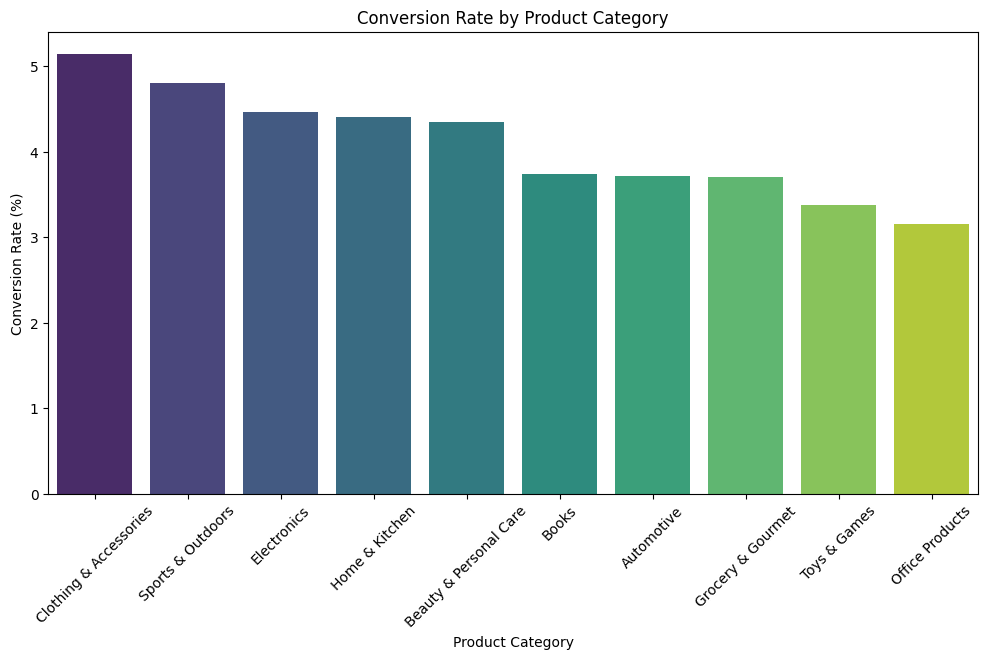

In [13]:
# Visualize Category Conversion Rates
plt.figure(figsize=(12, 6))
sns.barplot(data=category_cvr, x='category', y='conversion_rate_%', hue='category', palette='viridis', legend=False)
plt.title('Conversion Rate by Product Category')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.show()

### Clothing & Accessories Conversion by Device Type
We will now evaluate if device preference (Mobile vs. Desktop) impacts the conversion efficiency for our top-converting category.

In [14]:
# 1. Get all session IDs interested in Clothing & Accessories
clothing_product_ids = products[products['category'] == 'Clothing & Accessories']['product_id']
clothing_interactions = interactions[interactions['product_id'].isin(clothing_product_ids)]

# 2. Join with sessions to get device type
clothing_sessions_devices = pd.merge(
    clothing_interactions[['session_id']].drop_duplicates(),
    sessions[['session_id', 'device_type']],
    on='session_id'
)

# Count total unique sessions per device
device_traffic = clothing_sessions_devices.groupby('device_type').size().reset_index(name='total_sessions')

# 3. Join with purchases to find conversions
clothing_purchases = purchases[purchases['product_id'].isin(clothing_product_ids)]
clothing_conversions_devices = pd.merge(
    clothing_purchases[['session_id']].drop_duplicates(),
    sessions[['session_id', 'device_type']],
    on='session_id'
)

# Count converted unique sessions per device
device_conversions = clothing_conversions_devices.groupby('device_type').size().reset_index(name='converted_sessions')

# 4. Calculate Conversion Rate
device_cvr = pd.merge(device_traffic, device_conversions, on='device_type', how='left').fillna(0)
device_cvr['conversion_rate_%'] = (device_cvr['converted_sessions'] / device_cvr['total_sessions']) * 100

display(device_cvr)

,device_type,total_sessions,converted_sessions,conversion_rate_%
0,desktop,1648,80,4.854369
1,mobile,2937,165,5.617978
2,tablet,545,19,3.486239


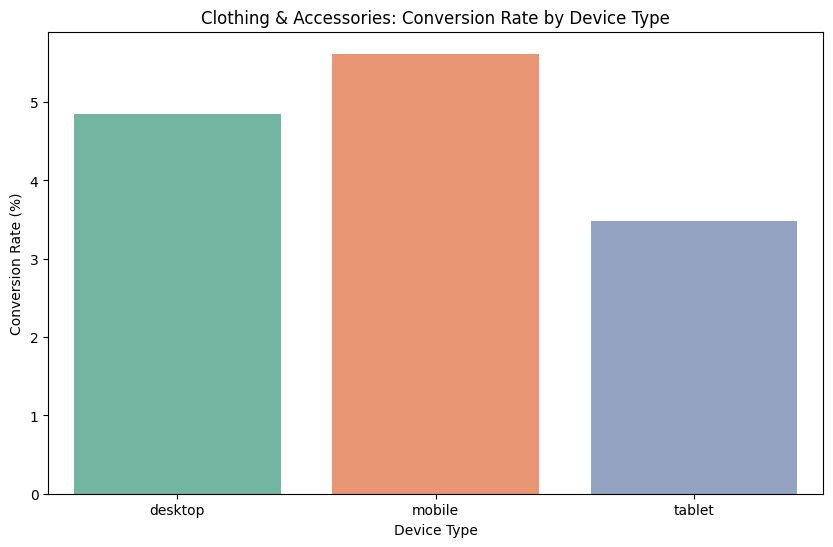

In [15]:
# Visualize Device Conversion Rates for Clothing & Accessories
plt.figure(figsize=(10, 6))
sns.barplot(data=device_cvr, x='device_type', y='conversion_rate_%', hue='device_type', palette='Set2', legend=False)
plt.title('Clothing & Accessories: Conversion Rate by Device Type')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Device Type')
plt.show()

### Electronics Conversion by Device Type
We will now evaluate how device type influences the conversion rate specifically for the **Electronics** category.

In [16]:
# 1. Get all session IDs interested in Electronics
electronics_product_ids = products[products['category'] == 'Electronics']['product_id']
electronics_interactions = interactions[interactions['product_id'].isin(electronics_product_ids)]

# 2. Join with sessions to get device type
electronics_sessions_devices = pd.merge(
    electronics_interactions[['session_id']].drop_duplicates(),
    sessions[['session_id', 'device_type']],
    on='session_id'
)

# Count total unique sessions per device
elec_device_traffic = electronics_sessions_devices.groupby('device_type').size().reset_index(name='total_sessions')

# 3. Join with purchases to find conversions
electronics_purchases = purchases[purchases['product_id'].isin(electronics_product_ids)]
electronics_conversions_devices = pd.merge(
    electronics_purchases[['session_id']].drop_duplicates(),
    sessions[['session_id', 'device_type']],
    on='session_id'
)

# Count converted unique sessions per device
elec_device_conversions = electronics_conversions_devices.groupby('device_type').size().reset_index(name='converted_sessions')

# 4. Calculate Conversion Rate
elec_device_cvr = pd.merge(elec_device_traffic, elec_device_conversions, on='device_type', how='left').fillna(0)
elec_device_cvr['conversion_rate_%'] = (elec_device_cvr['converted_sessions'] / elec_device_cvr['total_sessions']) * 100

display(elec_device_cvr)

,device_type,total_sessions,converted_sessions,conversion_rate_%
0,desktop,1666,75,4.501801
1,mobile,3097,139,4.488214
2,tablet,526,22,4.182510


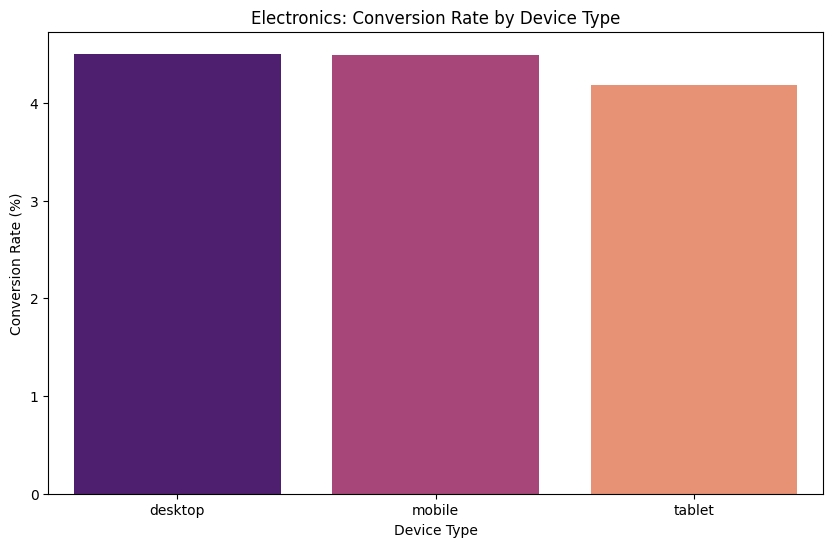

In [17]:
# Visualize Device Conversion Rates for Electronics
plt.figure(figsize=(10, 6))
sns.barplot(data=elec_device_cvr, x='device_type', y='conversion_rate_%', hue='device_type', palette='magma', legend=False)
plt.title('Electronics: Conversion Rate by Device Type')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Device Type')
plt.show()

### Revenue Trends by Product Category Over Time
In this section, we analyze the historical revenue performance of different categories to identify growth patterns and seasonality.

In [18]:
# 1. Prepare time-series data
purchases['order_date'] = pd.to_datetime(purchases['order_date'])
purchases['month_year'] = purchases['order_date'].dt.to_period('M')

# 2. Join purchases with products to get category labels
revenue_time_data = pd.merge(
    purchases[['order_date', 'total_amount', 'product_id', 'month_year']],
    products[['product_id', 'category']],
    on='product_id'
)

# 3. Aggregate revenue by month and category
category_trends = revenue_time_data.groupby(['month_year', 'category'])['total_amount'].sum().reset_index()
category_trends['month_year'] = category_trends['month_year'].dt.to_timestamp()

# Display the top performing months/categories
display(category_trends.sort_values(by=['month_year', 'total_amount'], ascending=[True, False]).head(10))

,month_year,category,total_amount
0,2023-01-01,Automotive,169.55
1,2023-01-01,Clothing & Accessories,16.21
2,2023-01-01,Grocery & Gourmet,11.48
9,2023-02-01,Sports & Outdoors,393.14
7,2023-02-01,Home & Kitchen,336.01
3,2023-02-01,Automotive,102.62
5,2023-02-01,Books,83.77
4,2023-02-01,Beauty & Personal Care,68.96
10,2023-02-01,Toys & Games,64.98
8,2023-02-01,Office Products,46.14


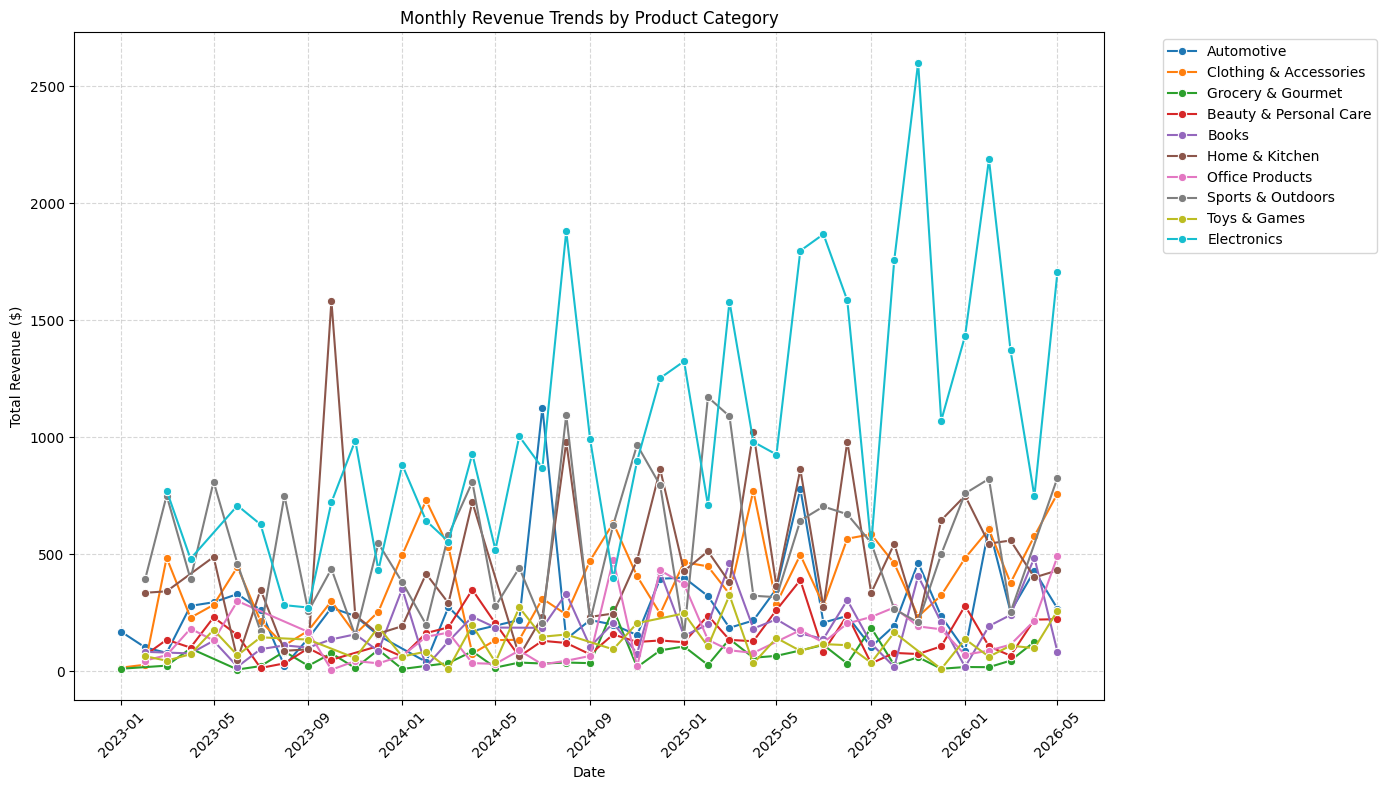

In [19]:
# 4. Visualize the trends
plt.figure(figsize=(14, 8))
sns.lineplot(data=category_trends, x='month_year', y='total_amount', hue='category', marker='o')

plt.title('Monthly Revenue Trends by Product Category')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Year-over-Year (YoY) Growth Analysis
In this section, we calculate the annual growth for both Revenue and Conversion Rates to evaluate long-term business performance.

In [20]:
# 1. Prepare Yearly Data
purchases['year'] = purchases['order_date'].dt.year
sessions['start_time'] = pd.to_datetime(sessions['start_time'])
sessions['year'] = sessions['start_time'].dt.year

# 2. Calculate Annual Revenue
yearly_revenue = purchases.groupby('year')['total_amount'].sum().reset_index(name='revenue')

# 3. Calculate Annual Conversion Rate
yearly_sessions = sessions.groupby('year').size().reset_index(name='total_sessions')
yearly_conversions = sessions.groupby('year')['is_converted'].sum().reset_index(name='total_conversions')
yearly_metrics = pd.merge(yearly_sessions, yearly_conversions, on='year')
yearly_metrics['conversion_rate'] = (yearly_metrics['total_conversions'] / yearly_metrics['total_sessions']) * 100

# 4. Merge Revenue with Metrics and Calculate Growth
yoy_data = pd.merge(yearly_revenue, yearly_metrics[['year', 'conversion_rate']], on='year')
yoy_data['rev_growth_%'] = yoy_data['revenue'].pct_change() * 100
yoy_data['cvr_growth_%'] = yoy_data['conversion_rate'].pct_change() * 100

display(yoy_data)

,year,revenue,conversion_rate,rev_growth_%,cvr_growth_%
0,2023,23610.80,6.788441,NaN,NaN
1,2024,37103.90,7.298109,57.148000,7.507890
2,2025,47738.66,7.774608,28.662108,6.529068
3,2026,21057.49,7.824043,-55.890069,0.635856


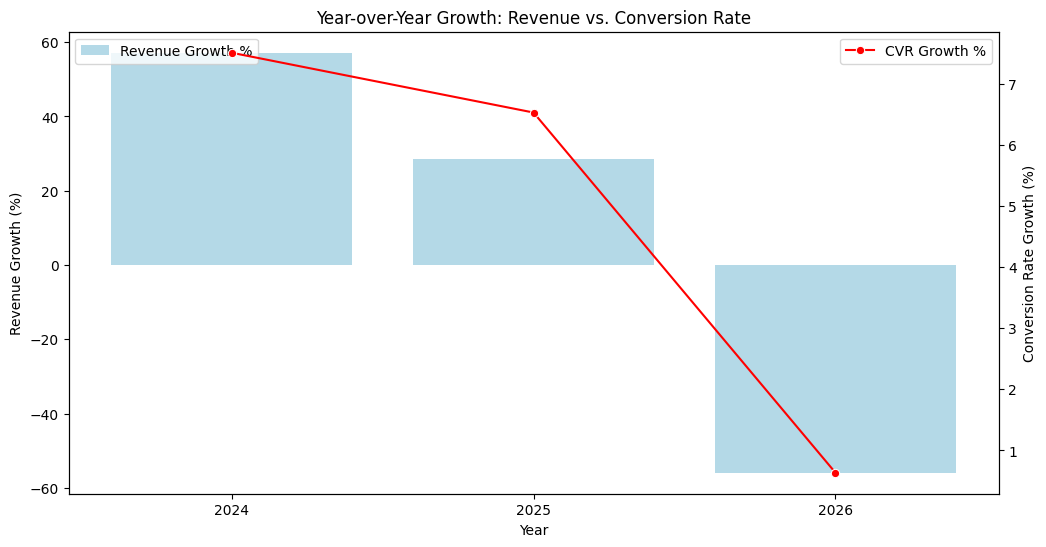

In [21]:
# 5. Visualize YoY Growth
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Revenue Growth
sns.barplot(x='year', y='rev_growth_%', data=yoy_data.dropna(), ax=ax1, color='skyblue', alpha=0.7, label='Revenue Growth %')
ax1.set_ylabel('Revenue Growth (%)')
ax1.set_xlabel('Year')

# Create a second y-axis for CVR growth
ax2 = ax1.twinx()
sns.lineplot(x=range(len(yoy_data.dropna())), y=yoy_data.dropna()['cvr_growth_%'], ax=ax2, marker='o', color='red', label='CVR Growth %')
ax2.set_ylabel('Conversion Rate Growth (%)')

plt.title('Year-over-Year Growth: Revenue vs. Conversion Rate')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

### Growth Comparison: High vs. Low Performing Categories
We now segment categories into 'High-Performing' and 'Low-Performing' groups to compare their growth trajectories.

In [24]:
# 1. Link purchases with revenue AND category
purchases_with_revenue_cat = pd.merge(
    purchases[['session_id', 'product_id', 'total_amount', 'order_date']],
    products[['product_id', 'category']],
    on='product_id'
)

# 2. Identify High vs Low categories based on total revenue
category_totals = purchases_with_revenue_cat.groupby('category')['total_amount'].sum().sort_values(ascending=False)
median_revenue = category_totals.median()

high_perf_cats = category_totals[category_totals >= median_revenue].index.tolist()
low_perf_cats = category_totals[category_totals < median_revenue].index.tolist()

print(f"High-Performing: {high_perf_cats}")
print(f"Low-Performing: {low_perf_cats}")

# 3. Calculate yearly revenue by segment
purchases_with_revenue_cat['performance_group'] = purchases_with_revenue_cat['category'].apply(lambda x: 'High' if x in high_perf_cats else 'Low')
purchases_with_revenue_cat['year'] = purchases_with_revenue_cat['order_date'].dt.year

segment_growth = purchases_with_revenue_cat.groupby(['year', 'performance_group'])['total_amount'].sum().reset_index()

# 4. Calculate % Growth
segment_growth['growth_%'] = segment_growth.groupby('performance_group')['total_amount'].pct_change() * 100

display(segment_growth.dropna())

High-Performing: ['Electronics', 'Sports & Outdoors', 'Home & Kitchen', 'Clothing & Accessories', 'Automotive']
Low-Performing: ['Books', 'Office Products', 'Beauty & Personal Care', 'Toys & Games', 'Grocery & Gourmet']


,year,performance_group,total_amount,growth_%
2,2024,High,29520.53,53.700166
3,2024,Low,7583.37,72.183787
4,2025,High,38889.69,31.737777
5,2025,Low,8848.97,16.689150
6,2026,High,17272.66,-55.585504
7,2026,Low,3784.83,-57.228581


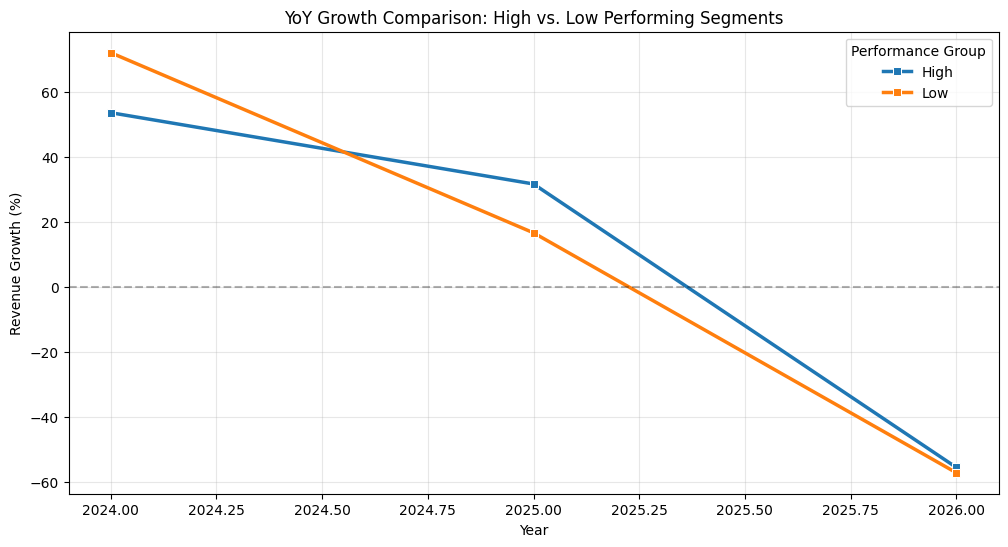

In [25]:
# 4. Visualize the comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=segment_growth.dropna(), x='year', y='growth_%', hue='performance_group', marker='s', linewidth=2.5)

plt.title('YoY Growth Comparison: High vs. Low Performing Segments')
plt.ylabel('Revenue Growth (%)')
plt.xlabel('Year')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.legend(title='Performance Group')
plt.show()

### Identifying 2024 Top-Selling Products in Low-Performing Categories
This analysis identifies which specific items drove the 72.2% growth spike for the 'Low' performance group.

In [26]:
# 1. Filter for low-performing categories and the year 2024
low_perf_2024 = purchases_with_revenue_cat[
    (purchases_with_revenue_cat['performance_group'] == 'Low') &
    (purchases_with_revenue_cat['year'] == 2024)
].copy()

# 2. Join with products to get product names (assuming 'product_name' or similar exists, otherwise using IDs)
# Let's check columns first or just use product_id and category
top_products_2024 = low_perf_2024.groupby(['product_id', 'category']).agg(
    total_revenue=('total_amount', 'sum'),
    quantity_sold=('product_id', 'count')
).reset_index().sort_values(by='total_revenue', ascending=False)

# 3. Display Top 10 products contributing to the surge
print("Top 10 Products in Low-Performing Categories (2024 Surge):")
display(top_products_2024.head(10))

Top 10 Products in Low-Performing Categories (2024 Surge):


,product_id,category,total_revenue,quantity_sold
18,341db25d-1cfb-4b01-8303-070a169d0c56,Books,875.60,13
60,c2e39751-db17-424f-8d71-61ec7ecad424,Beauty & Personal Care,662.90,12
58,c1ab2206-9b50-4aaa-9446-f322d0976ea6,Books,594.64,14
1,09103a95-db77-427f-82f9-14d9d18d0a88,Office Products,463.79,4
13,25a6c99c-d63c-4697-91ef-744b7879d605,Office Products,413.63,9
56,bc7a0ca1-564a-47cf-a592-8c5e99a37981,Toys & Games,374.04,5
7,15aab0b8-557b-4fed-b273-06eee86de77d,Beauty & Personal Care,333.72,5
14,26fa0037-c745-4789-8a44-9f3dfb7f25f7,Grocery & Gourmet,330.86,9
62,c6e6f549-6d3f-41a8-aad5-d0e89af54109,Office Products,277.00,4
54,b21e2f4d-ad9a-43bd-a87a-71d341f33051,Books,257.26,4


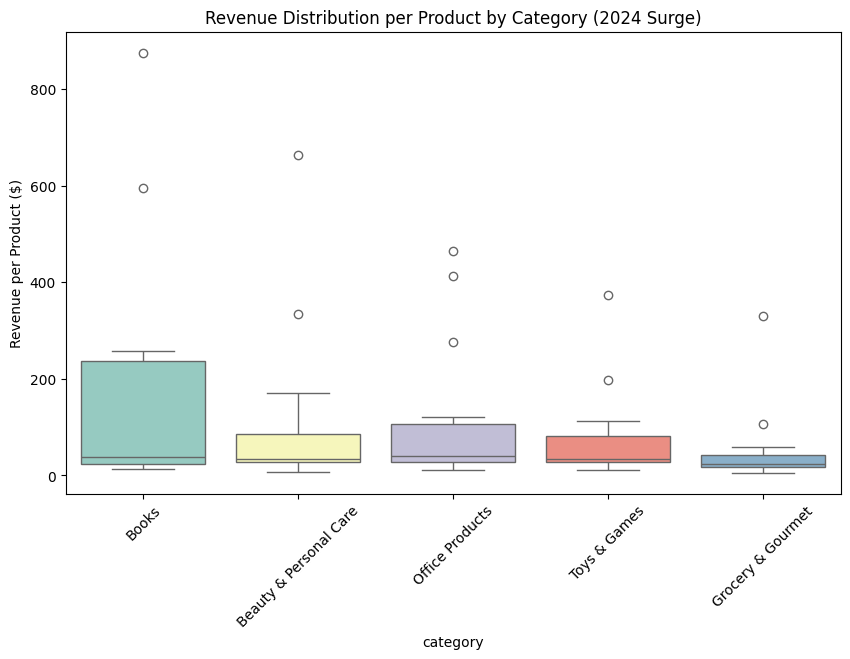

In [27]:
# 4. Visualize Revenue Concentration
plt.figure(figsize=(10, 6))
sns.boxplot(data=top_products_2024, x='category', y='total_revenue', palette='Set3', hue='category', legend=False)
plt.title('Revenue Distribution per Product by Category (2024 Surge)')
plt.ylabel('Revenue per Product ($)')
plt.xticks(rotation=45)
plt.show()

### Exporting Visualizations
The following code saves all generated plots and prepares them for download.

In [30]:
import matplotlib.pyplot as plt
import os
import zipfile
from google.colab import files

# Create directory
img_dir = 'analysis_visuals'
os.makedirs(img_dir, exist_ok=True)

def save_plot(name):
    plt.savefig(f"{img_dir}/{name}.png", bbox_inches='tight')
    plt.close()

# 1. Revenue by Channel
plt.figure(figsize=(12, 6))
sns.barplot(data=channel_metrics, x='referrer_source', y='total_revenue', palette='viridis')
plt.title('Total Revenue by Channel')
plt.xticks(rotation=45)
save_plot('revenue_by_channel')

# 2. Conversion Rate by Channel
plt.figure(figsize=(12, 6))
sns.barplot(data=channel_metrics, x='referrer_source', y='conversion_rate', palette='magma')
plt.title('Conversion Rate by Channel')
plt.xticks(rotation=45)
save_plot('cvr_by_channel')

# 3. Revenue Per Session
plt.figure(figsize=(12, 6))
sns.barplot(data=profitable_channels, x='referrer_source', y='rev_per_session', palette='coolwarm')
plt.title('Revenue per Session by Channel')
save_plot('rev_per_session')

# 4. Monthly Trends
plt.figure(figsize=(14, 8))
sns.lineplot(data=category_trends, x='month_year', y='total_amount', hue='category', marker='o')
plt.title('Monthly Revenue Trends')
save_plot('monthly_trends')

# 5. YoY Growth Segment Comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=segment_growth.dropna(), x='year', y='growth_%', hue='performance_group', marker='s')
plt.title('YoY Growth Comparison')
save_plot('yoy_growth_segments')

# 6. Revenue Distribution (Low-Perf Surge)
plt.figure(figsize=(10, 6))
sns.boxplot(data=top_products_2024, x='category', y='total_revenue', palette='Set3')
plt.title('2024 Revenue Distribution per Product')
save_plot('low_perf_distribution_2024')

# Zip the directory
zip_filename = 'analysis_visuals.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files_in_dir in os.walk(img_dir):
        for file in files_in_dir:
            zipf.write(os.path.join(root, file), file)

files.download(zip_filename)
print(f'Successfully saved and prepared {zip_filename} for download.')

/tmp/ipykernel_1617/1738634333.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_metrics, x='referrer_source', y='total_revenue', palette='viridis')
/tmp/ipykernel_1617/1738634333.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_metrics, x='referrer_source', y='conversion_rate', palette='magma')
/tmp/ipykernel_1617/1738634333.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profitable_channels, x='referrer_source', y='rev_per_session', palette='coolwarm')
/tmp/ipykernel_1617/1738634333.py:48: FutureW

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully saved and prepared analysis_visuals.zip for download.


# Executive Summary: E-commerce Performance Analysis

### 1. Financial Growth & Momentum
*   **Revenue Growth**: The business experienced a massive **57.1% revenue surge in 2024**, followed by a healthy **28.7% growth in 2025**.
*   **Conversion Efficiency**: Overall Conversion Rate (CVR) has consistently improved every year, reaching a peak of **7.82% in 2026**.

### 2. Marketing Channel ROI
*   **Primary Volume Driver**: **Organic Search** and **Direct** traffic drive the bulk of absolute revenue.
*   **Efficiency Leader**: **Display Ads** are the most profitable channel on a per-visit basis, generating **$8.98 per session** with a top-tier conversion rate of **10.6%**.

### 3. Category & Device Performance
*   **Top Categories**: **Electronics** ($40k+) and **Sports & Outdoors** ($21k+) are the primary revenue engines.
*   **Mobile Dominance**: In the **Clothing & Accessories** category, mobile users convert at **5.62%**, significantly outperforming desktop. However, for high-consideration items like **Electronics**, conversion is balanced across all devices (~4.5%).
*   **Growth Volatility**: 'Low-Performing' categories (Books, Beauty) saw a **72.2% growth spike in 2024**, which analysis revealed was due to a small number of 'hit' products rather than broad category expansion.

### 4. Strategic Recommendations
1.  **Scale High-Efficiency Channels**: Reallocate marketing budget toward **Display Ads** to capitalize on their high revenue-per-session.
2.  **Mobile UX Optimization**: Prioritize mobile-first design for the **Clothing** segment where users show a clear preference for handheld shopping.
3.  **Inventory Diversification**: Reduce reliance on 'hit' products in the Books and Beauty segments to create more sustainable and predictable growth patterns.

---
*Analysis by Holarbrain · github.com/holarbrain*